# **Potential Visualization Notebook**  

This notebook provides a structured workflow for analyzing and visualizing the **Chiral Potential** that we aim to develop to model the **empirical one** with DFTB. The analysis is conducted using modular Python scripts.

---

## Workflow Overview   

1. **Modified Lennard Jones Potential** – the implementation of cos() term to consider rotation of particles.
2. **Chiral Potential Visualization** – Adding the effect of reletive facing, more that global rotation to consider chirality effect on pair interaction.


---
# Chiral Potential Development

#### Current Modified Lennard-Jones Potential
We previously introduced a modified Lennard-Jones potential with an angular term to control rotational periodicity:

$$
U_{LJmod} = 4.0 \epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right] + A(r) \left( 1 + \cos(n \Delta \phi + \alpha) \right)
$$

#### Chiral Potential Extension
To introduce chirality, we must account for:
1. Handedness ($h$) and orientation ($d$) of each particle
2. Relative facing angle between helix pairs

The key modifications are:

1. **Orientation Transformation**:
$$
\phi_{i,\text{new}} = h_i d_i (\phi_i - \gamma_{ij})
$$
where the relative angle is:
$$
\gamma_{ij} = \arctan\left( \frac{y_j - y_i}{x_j - x_i} \right)
$$

2. **New Phase Difference**:
$$
\Delta \phi_{\text{new}} = \phi_{j,\text{new}} - \phi_{i,\text{new}}
$$

Final Chiral Potential ->
$$
U_{\text{LJmod, chiral}} = 4.0 \epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right] + A(r) \left( 1 + \cos(n \Delta \phi_{\text{new}} + \alpha) \right)
$$
where A(r) is:
$$
A(r) = \frac{A_0}{r^m}
$$

Implementation Notes
- $h_i$: Handedness (R=+1, L=-1)
- $d_i$: Orientation (U=+1, D=-1)
- $\theta_{ij}$: Relative azimuthal angle between particles
- The $\cos(n \Delta \phi_{\text{new}} + \alpha)$ term now properly accounts for chiral interactions

In [23]:
import visualization

heatmap_potential, heatmap_potential_polar = visualization.create_interactive_plots_LJmod()
display(heatmap_potential, heatmap_potential_polar)

interactive(children=(IntSlider(value=2, description='φ order:', max=10, min=1), FloatSlider(value=1.6, descri…

interactive(children=(IntSlider(value=2, description='φ order:', max=10, min=1), FloatSlider(value=1.6, descri…

In [24]:
import visualization

heatmap_potential_chiral = visualization.create_interactive_plots_LJmod_pair()
display(heatmap_potential_chiral)

interactive(children=(Dropdown(description='Potential type:', options=('RRUU', 'RLUU', 'RRUD', 'RLUD'), value=…

---
# New Chiral Potential Development (rotation-aware form)

#### Alternative Chiral Potential Formulation
To explore a more flexible implementation of chirality, we introduce a coupling between particle rotation and relative position through a linear chiral term added to the standard Lennard-Jones (LJ) interaction:

$$
U_{\text{mod}} = U_{\text{LJ}} + V, \quad \text{where} \quad U_{\text{LJ}} = 4 \epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right]
$$

#### Chirality-Inducing Interaction Term
The chiral coupling is implemented via:

$$
V = v_i Q_j + v_j Q_i
$$

with:
- $ v_i = F(r, \psi_i) \cdot Q(\psi_i) $
- $ \psi_i = \phi_i - \gamma $
- $ \gamma = \arctan2(y_j - y_i, x_j - x_i) $

Here, $\psi_i$ describes the rotation of particle $i$ relative to the connecting line between particles $i$ and $j$.

#### Example Functional Forms
To keep the model general, $F$ and $Q$ can be freely chosen. In our default implementation, we use:

- Orientation-dependent modulation:
  $$
  Q(\psi) = \sin(\psi)
  $$

- Distance-dependent decay:
  $$
  F(r, \psi) = \frac{C}{r^m}
  $$

Thus, the full chiral interaction becomes:

$$
V = \frac{C}{r^m} \left[ \sin(\psi_i) \sin(\psi_j) + \sin(\psi_j) \sin(\psi_i) \right] = \frac{2C}{r^m} \sin(\psi_i) \sin(\psi_j)
$$

#### Final Potential Expression
Putting everything together:

$$
U_{\text{mod}} = 4 \epsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right] + \frac{2C}{r^m} \sin(\psi_i) \sin(\psi_j)
$$

---

#### Implementation Notes
- $ \phi_i $: Absolute orientation of particle $ i $
- $ \gamma $: Angle of inter-particle vector (chirality reference axis)
- $ C $: Chiral interaction strength


In [ ]:
import visualization

heatmap_potential, heatmap_potential_polar = visualization.create_interactive_chiral_new(pot_kwargs={'field_kwargs':{'period':3}})
display(heatmap_potential, heatmap_potential_polar)

In [ ]:
import numpy as np
#potential_chiral_pair = visualization.create_interactive_plots_chiral_new_pair(pot_kwargs={'field_kwargs':{'period':3}, 'charge':lambda psi2: np.sin((np.pi - psi2)*18)})
potential_chiral_pair = visualization.create_interactive_plots_chiral_new_pair(pot_kwargs={'field_kwargs':{'period':6}})
display(potential_chiral_pair)

In [ ]:
import visualization

import numpy as np
potential_chiral_pair = visualization.create_interactive_plots_chiral_new_pair_psi(pot_kwargs={'field_kwargs':{'period':3}, 'charge':lambda psi2: np.sin((np.pi/2 - psi2)*18)})
#potential_chiral_pair = visualization.create_interactive_plots_chiral_new_pair_psi(pot_kwargs={'field_kwargs':{'period':6}})
display(potential_chiral_pair)

---

### New Suggestion: Rotation consideration in r of Lennard-Jones



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def lennard_jones_base(r, sigma=1, epsilon=1):
    if np.any(r <= 0):
        raise ValueError("Distance r must be greater than zero.")
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

def r_LJ (xi, yi, xj, yj, phi_i=0, phi_j=0, radius=1):
    x = xj - xi + radius * (np.cos(phi_j) - np.cos(phi_i))
    y = yj - yi + radius * (np.sin(phi_j) - np.sin(phi_i))

    r = x**2 + y**2

    return np.sqrt(r)

d = 1.3
data = r_LJ(0, 0, np.array(d, d * np.cos(0: 2 * np.pi)), np.array(d, d * np.sin(0: 2 * np.pi)))
data2 = lennard_jones_base(r_LJ)

plt.heatmap(data2)

interactive(children=(FloatSlider(value=1.8, description='Centers Distance:', max=5.0, min=1.0), FloatSlider(v…

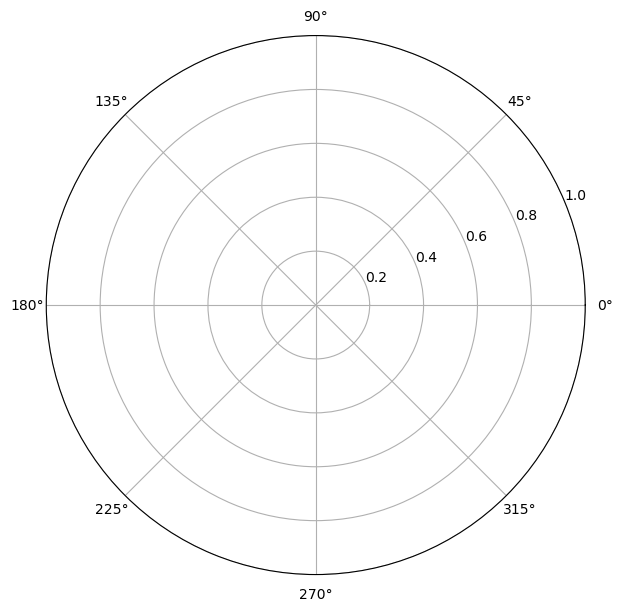

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets

def lennard_jones_base(r, sigma=1, epsilon=1):
    """Calculate the Lennard-Jones potential."""
    if np.any(r <= 0):
        return np.inf
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

def r_LJ(xi, yi, xj, yj, phi_i=0, phi_j=0, radius=1):
    """Calculate the effective distance considering rotation."""
    x = xj - xi + radius * (np.cos(phi_j) - np.cos(phi_i))
    y = yj - yi + radius * (np.sin(phi_j) - np.sin(phi_i))
    return np.sqrt(x**2 + y**2)

# Parameters
sigma = 1.0
epsilon = 1.0
radius = 0.5

def plot_potential_LJ_in(d, phi_i, phi_j):
    theta = np.linspace(0, 2* np.pi, 100)

    xi, yi = 0, 0
    xj, yj = d*np.cos(theta), d*np.sin(theta)
    Xj, Yj = np.meshgrid(xj, yj)

    effective_distances = r_LJ(xi, yi, Xj, Yj, phi_i, phi_j, radius)
    potential = lennard_jones_base(effective_distances, sigma, epsilon)

    D, Theta = np.meshgrid(d, theta)
    
    fig, axs = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))
      
    # Plot the heatmap
    c1 = axs.contourf(Theta, D, potential, levels=100, cmap="viridis")
    fig.colorbar(c1, ax=axs, label='Potential')

    plt.title('Modified Lennard-Jones Potential')

    plt.grid(False)
    plt.tight_layout()
    plt.show()

def interactive_plot_LJ_in():
    distance_slider = ipywidgets.FloatSlider(value=1.8, min=1, max=5, step=0.1, description='Centers Distance:')
    phi_i_slider = ipywidgets.FloatSlider(value=0, min=0, max=2*np.pi, step=np.pi/8, description='φ_i:')
    phi_j_slider = ipywidgets.FloatSlider(value=0, min=0, max=2*np.pi, step=np.pi/8, description='φ_j:')
    
    heatmap_potential = ipywidgets.interactive(
        plot_potential_LJ_in,
        d=distance_slider,
        phi_i=phi_i_slider,
        phi_j=phi_j_slider
    )
    
    return heatmap_potential

potential_LJ_in = interactive_plot_LJ_in()
display(potential_LJ_in)